In [1]:
from bias import Bias

In [2]:
from observations import Observations
from models_physical import VdP


obs = Observations(model=VdP, 
                    t_start=2.0, 
                    t_stop=2.5, 
                    Nt_obs=50, 
                    add_noise=True,
                    Nq=2,
                    noise_type='gauss, add',
                    noise_level=0.1,
                    manual_bias='linear'
                    )


...Applying manual bias: linear
...Adding noise: gauss, add with level 0.1.
OK: Observations initialized.


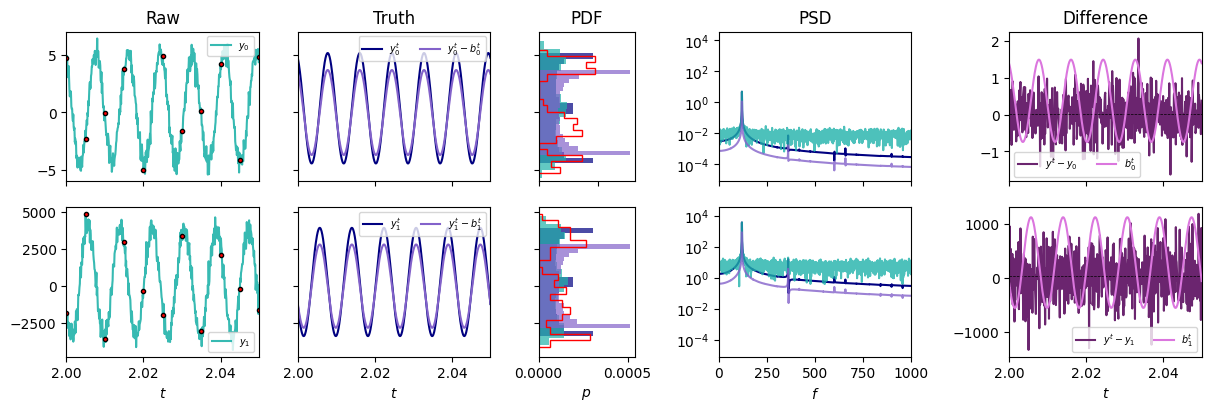

In [3]:

Observations.plot_truth(obs, f_max=1000, window=.05)

We want to model the truth $y^{true}$ using a reduced order model, which may be biased. In this twin experiment case, the ROM is  show in the figure above as $y^{true}-b^{true}$.


To infer the bias $b^{true}$ from the obsdervation data $d$ (red dots) without knowing the truth $y^{true}$, we need to make some assumtions. First, we will assume that we have a model of the system which gives some estimate of the system as 
$$
y^{rom}(t) = y^{true}(t) + b^{true}(t) + \varepsilon_y
$$
and the observations 
$$
d(t^{obs}) = y^{true}(t^{obs}) + \varepsilon_{obs}, 
$$
where $\varepsilon$ is noise. 

✗ No matching config found
No matching config 647dfbc95583033c found in /storage0/anovoama/real-time-bias-aware-DA/src/config/esn_configs.
Loaded file is invalid: <class 'bool'>: False
Creating training data for bias model...


 Preparing reference data for training...
y_model_L shape: (4600, 2, 1)
Training ESN model...


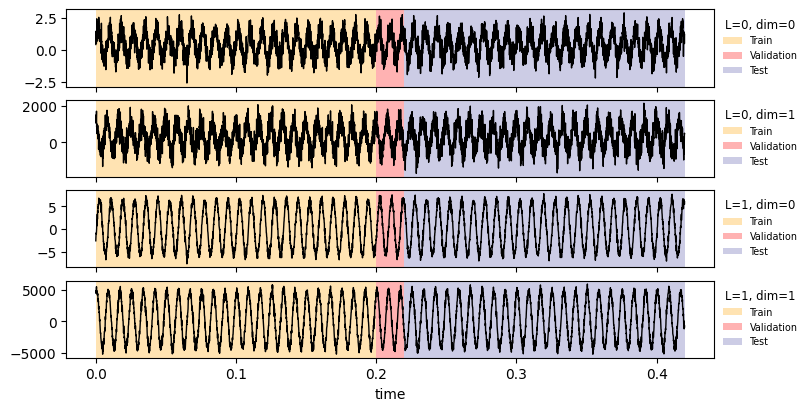

Modifying N_dim = 2 -> 2 at training.

 ----------------- HYPERPARAMETER SEARCH ------------------
 4x4 grid and 4 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 1.000e-02	 1.000e-06	 -1.1495
2	 2.000e-01	 2.154e-01	 1.000e-06	 -1.0137
3	 2.000e-01	 4.642e+00	 1.000e-06	 -1.1475
4	 2.000e-01	 1.000e+02	 1.000e-06	 -0.4595
5	 4.000e-01	 1.000e-02	 1.000e-06	 -0.8872
6	 4.000e-01	 2.154e-01	 1.000e-06	 -0.9703
7	 4.000e-01	 4.642e+00	 1.000e-06	 -1.1765
8	 4.000e-01	 1.000e+02	 1.000e-12	 -0.4232
9	 6.000e-01	 1.000e-02	 1.000e-06	 -0.5296
10	 6.000e-01	 2.154e-01	 1.000e-06	 -0.8875
11	 6.000e-01	 4.642e+00	 1.000e-06	 -1.1711
12	 6.000e-01	 1.000e+02	 1.000e-12	 -0.4728
13	 8.000e-01	 1.000e-02	 1.000e-06	 -0.6931
14	 8.000e-01	 2.154e-01	 1.000e-06	 -0.9471
15	 8.000e-01	 4.642e+00	 1.000e-06	 -1.1599
16	 8.000e-01	 1.000e+02	 1.000e-06	 -0.4769
17	 4.840e-01	 3.795e+00	 1.000e-06	 -1.1679
18	 8.000e-01	 1.762e+00	 1.000e-06	 -1.1449
19	 2.464e-01	 1.

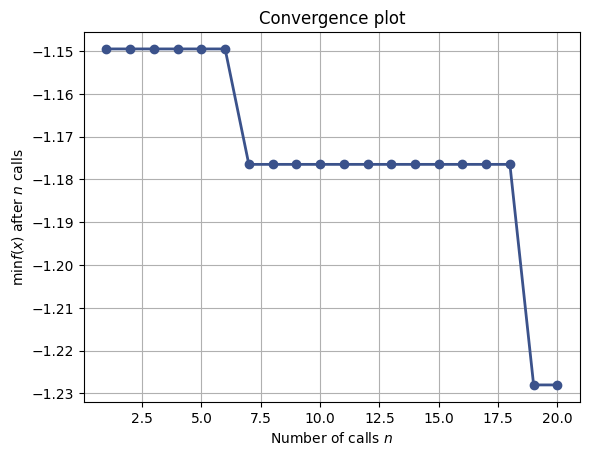

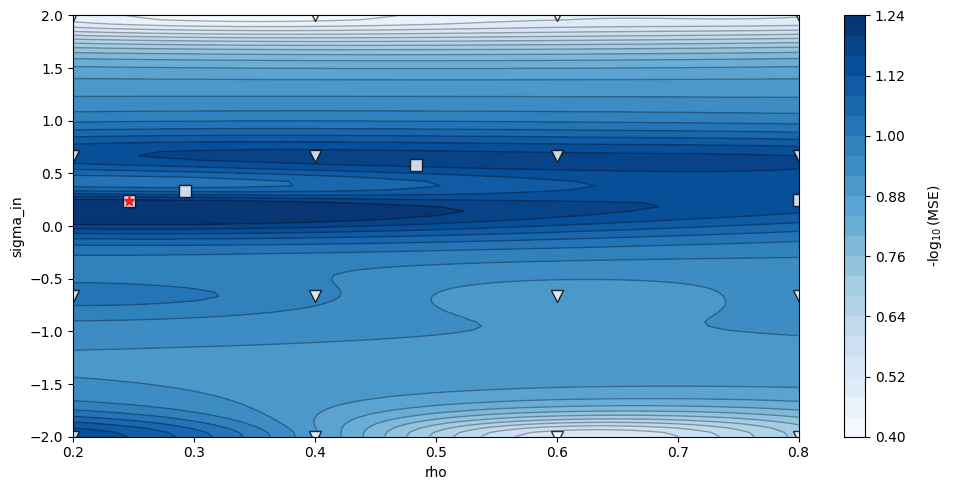

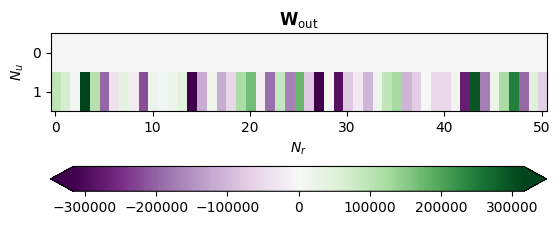

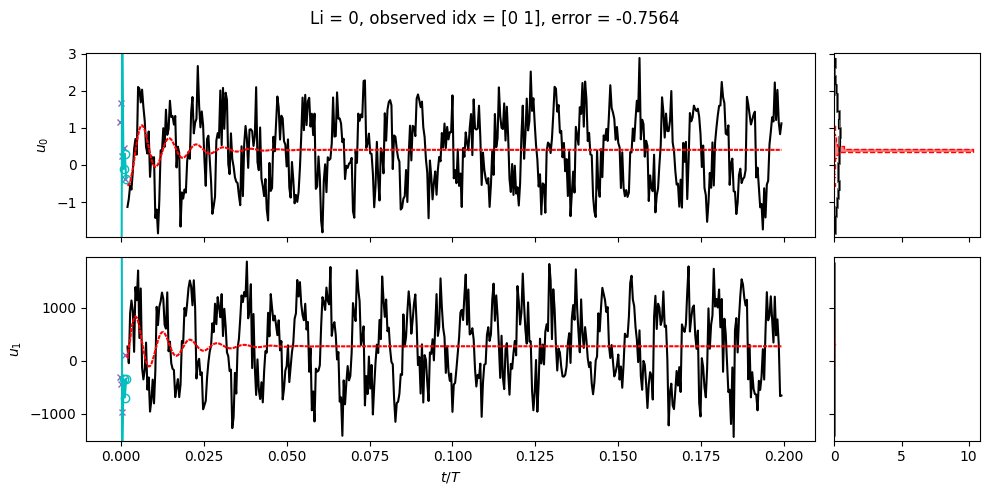

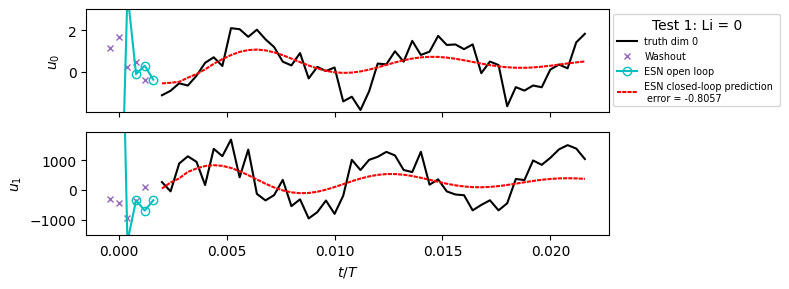

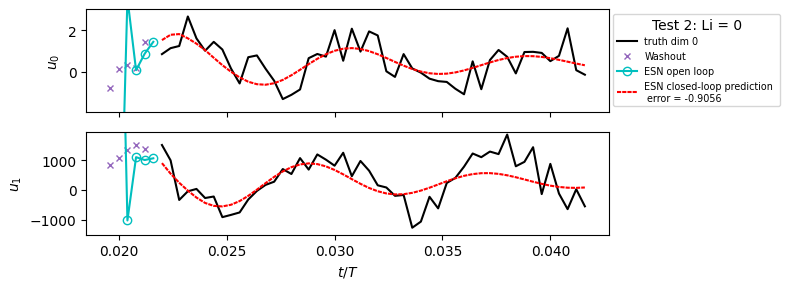

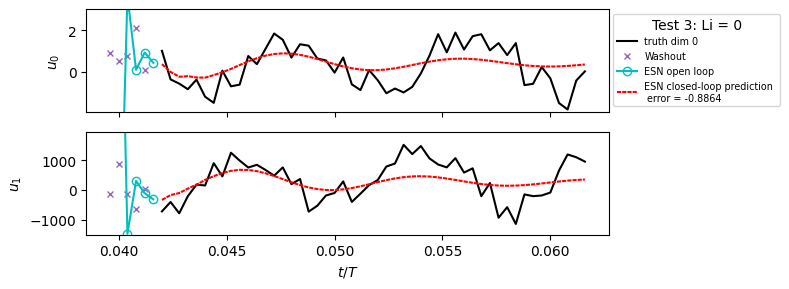

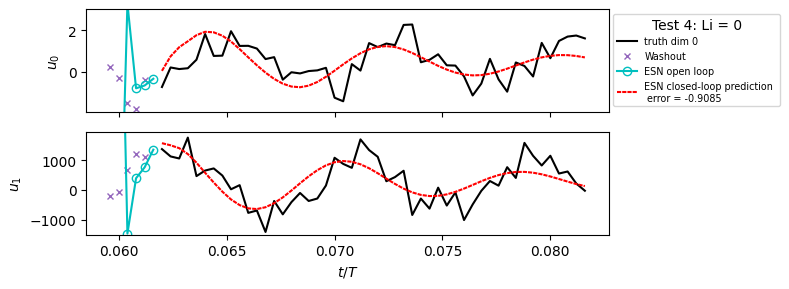

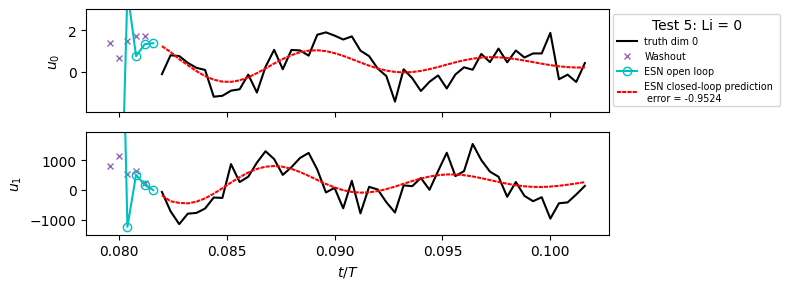

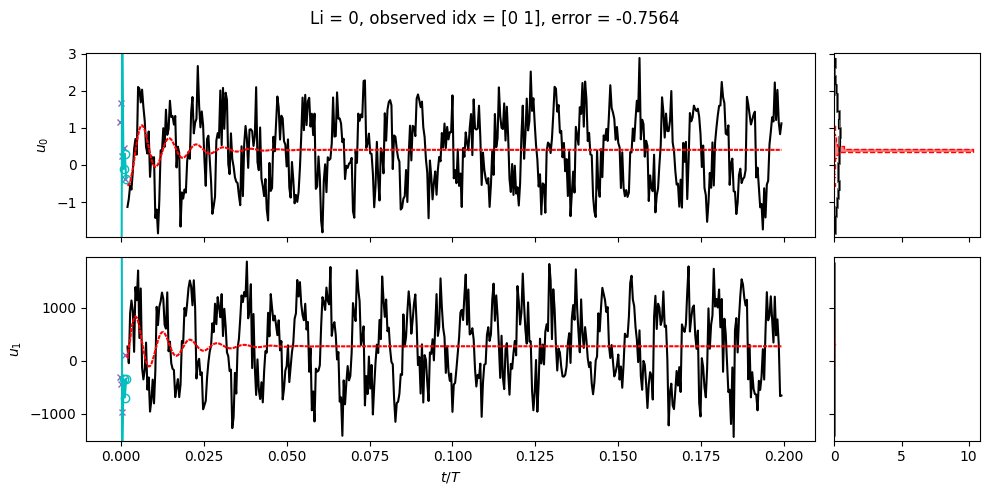

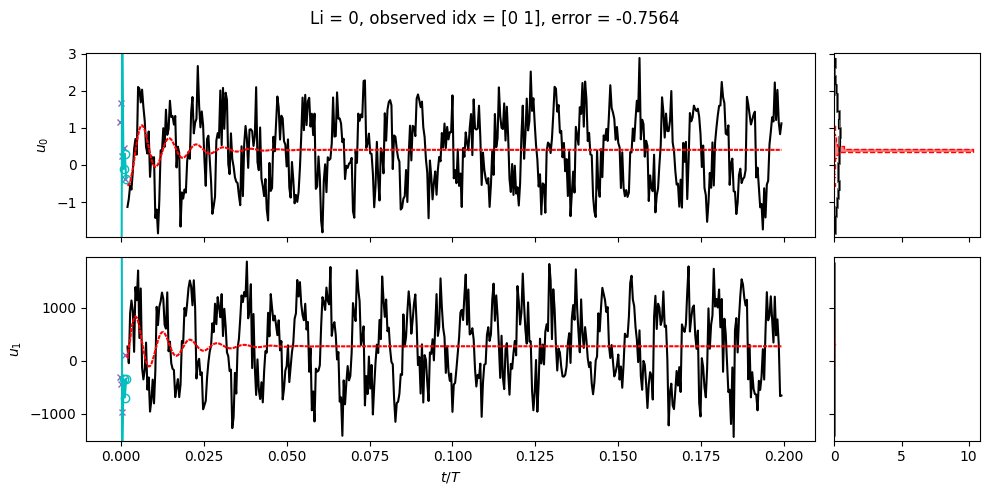

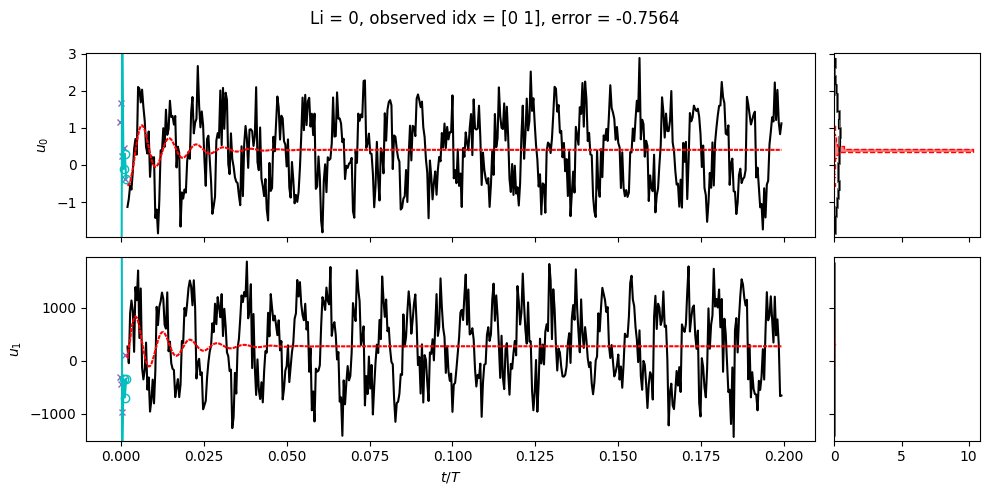

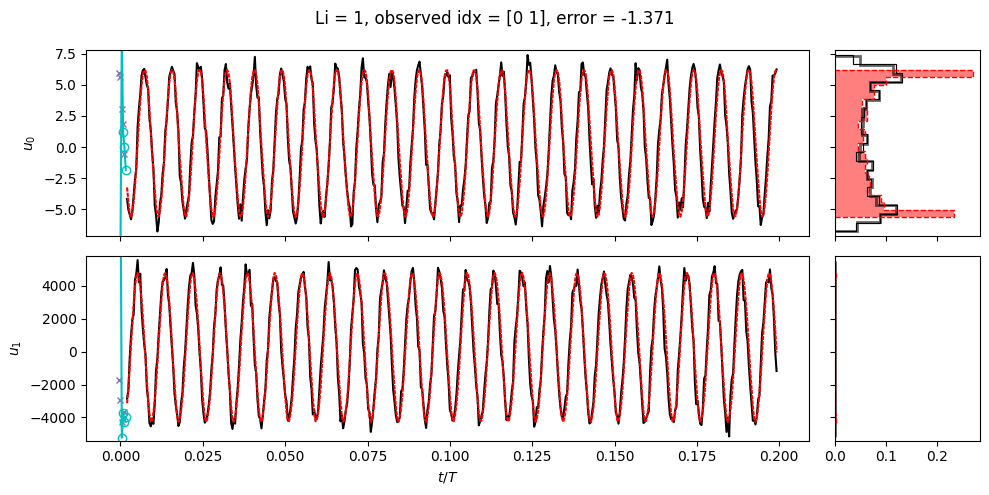

In [5]:
from bias_estimators import ESN_bias
from utils import set_working_directories 
from pathlib import Path

# First, initialize a ROM 
rom = VdP(Nq=2
    )


results_dir = set_working_directories('VdP')[1]

training_data_filename = Path(results_dir) / 'Tutorial_05_bias_training_data2'


# Then, initialize a Bias object using the ROM and the Observations
bias = ESN_bias(rom=rom,
                reference_data=obs,
                t_min=0.5,
                t_max=2.0,
                training_data_filename=training_data_filename,
                # Parameters for training data generation (if no file found or loading fails)
                std_phi=0.1,
                std_alpha=0.1,
                biased_observations=False,
                # Other parameters for the bias model can be added here as needed
                N_units=50,
                auto_save=True,
                N_func_evals=20,
                N_grid=4,
                t_train=0.2, 
                t_val=0.02,
                upsample=4
                )


In [6]:
bias.print_bias_parameters()


 ---------------- Bias model parameters --------------- 
	 Bias class name: ESN_bias
	 bayesian_update = False
	 biased_observations = False
	 upsample = 4
	 Model class name: ESN_model
	 N_units = 50
	 N_wash = 5
	 rho = 0.246393
	 sigma_in = 1.718602
	 update_reservoir = True
	 update_state = True
	 upsample = 4
